In [13]:
from c3s_lib import *

import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx


In [2]:
# api key used for the DataClient
# replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

In [3]:
#2.1
# example of retrieving data for 15 days leading up to an event
eventDate = datetime(2020, 1, 1)        # event date
startDate = eventDate - timedelta(days=14)  # 15 days before the event date range is inclusive
bbox = (-5.0, -10.0, 15.0, 20.0)

# retrieve the data for the specified bounding box and date range
gdfs = DataClient(your_api_key).temperature_2m_mean(bbox, (startDate, eventDate))

2025-08-20 14:31:56,034 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-20 14:31:59,998 INFO Request ID is 45173e6d-cd71-4089-9949-fdcf9d6fa2d1
2025-08-20 14:32:01,932 INFO status has been updated to accepted
2025-08-20 14:32:11,265 INFO status has been updated to running
2025-08-20 14:32:24,049 INFO status has been updated to successful


4c84bcc74f06ef7409c33773069e9a4b.nc:   0%|          | 0.00/303k [00:00<?, ?B/s]

2025-08-20 14:32:27,466 INFO Request ID is dcace0e0-5658-4e20-9251-ff9c062d196a
2025-08-20 14:32:29,533 INFO status has been updated to accepted
2025-08-20 14:32:44,986 INFO status has been updated to successful


8c7783fe14740279ff110147ba00dee.nc:   0%|          | 0.00/42.8k [00:00<?, ?B/s]

In [4]:
#2.1
# split dataframe into daily GeoDataFrames
daily_gdfs = {}
for date, gdf in gdfs.groupby(gdfs['valid_time'].dt.date):
    daily_gdfs[date] = gdf

# or make a selection of the data for a specific date range
gdf_selection = gdfs[(gdfs['valid_time'] >= eventDate) & (gdfs['valid_time'] <= eventDate)]

gdf_selection

,valid_time,latitude,longitude,t2m,number,geometry
137214,2020-01-01,20.0,-5.00,12.248108,0,POINT (-5 20)
137215,2020-01-01,20.0,-4.75,12.326660,0,POINT (-4.75 20)
137216,2020-01-01,20.0,-4.50,12.396973,0,POINT (-4.5 20)
137217,2020-01-01,20.0,-4.25,12.505188,0,POINT (-4.25 20)
137218,2020-01-01,20.0,-4.00,12.623047,0,POINT (-4 20)
...,...,...,...,...,...,...
147010,2020-01-01,-10.0,14.00,28.377686,0,POINT (14 -10)
147011,2020-01-01,-10.0,14.25,28.002930,0,POINT (14.25 -10)
147012,2020-01-01,-10.0,14.50,26.457520,0,POINT (14.5 -10)
147013,2020-01-01,-10.0,14.75,24.258453,0,POINT (14.75 -10)


In [ ]:
def ddplot_gdf(gdf, borders=True, coastlines=True, gridlines=True, title=None, legend=True, legend_title=None, value_col='t2m', cmap='coolwarm', fig_size = (7,5), polygons:Polygon = None, projection=ccrs.PlateCarree(), extends:tuple[float, float, float, float]=None):
    
    fig, ax = plt.subplots(
        ncols = 1, nrows = 1, figsize = fig_size, dpi = 100, 
        subplot_kw = {"projection" : projection}
        )   

    # set color map   
    #vmin = -50
    #vmax = 50   # this should be variable based on temp or precipitation
    temp_kwargs = {"cmap" : cmap}

    # Set the colorbar properties
    legend_title = legend_title if legend_title else "legend"

    # Plot the GeoDataFrame
    gdf.plot(ax = ax, **temp_kwargs,
        legend=legend, legend_kwds={'label': legend_title},
        column = value_col,
        )

    # Add contextily basemap
    if gridlines:
        ax.gridlines(
            crs=projection, 
            linewidth=0.5, color='black', 
            draw_labels=["bottom", "left"], alpha=0.2
        )

    # Add coastlines
    if coastlines:
        ax.coastlines()

    # Add contextily basemap
    if borders:
        ax.add_feature(
            cartopy.feature.BORDERS, 
            lw = 1, alpha = 0.7, ls = "--", zorder = 99
        )

    # Draw polygons if provided
    if polygons is not None:
        for poly in polygons:
            x, y = poly.exterior.xy
            ax.plot(x, y, color='red', linewidth=2, transform=projection)

    # add box around area of interest
    if title is not None:
        ax.set_title(title)

    # Set extent if provided
    if extends is not None:
      ax.set_extent(extends, crs=projection)

    return fig, ax


In [47]:
def ddsubplot_gdf(
    gdfs, datetime_col='valid_time', column='t2m', polygons=None,
    ncols=5, figsize=(20, 12), cmap='coolwarm', legend_title='Temperature (°C)',
    borders=True, coastlines=True, gridlines=True, suptitle=None
):
    # Ensure datetime column is datetime type
    gdfs[datetime_col] = pd.to_datetime(gdfs[datetime_col])

    # Unique days sorted
    unique_days = sorted(gdfs[datetime_col].dt.date.unique())
    n_plots = len(unique_days)
    nrows = math.ceil(n_plots / ncols)

    # Create subplots with Cartopy projection
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize,
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axes = axes.flatten()

    # Normalize color scale across all data
    vmin = gdfs[column].min()
    vmax = gdfs[column].max()

    for i, day in enumerate(unique_days):
        ax = axes[i]

        # Filter GeoDataFrame for this day
        day_gdf = gdfs[gdfs[datetime_col].dt.date == day]

        # Plot data on this subplot
        day_gdf.plot(
            ax=ax,
            column=column,
            cmap=cmap,
            legend=False,  # legend handled once globally
            vmin=vmin,
            vmax=vmax,
        )

        if gridlines:
            ax.gridlines(
                crs=ccrs.PlateCarree(),
                linewidth=0.5,
                color='black',
                draw_labels=["bottom", "left"],
                alpha=0.2
            )

        if coastlines:
            ax.coastlines()

        if borders:
            ax.add_feature(cartopy.feature.BORDERS, lw=1, alpha=0.7, ls="--")

        # Draw polygons if provided
        if polygons is not None:
            for poly in polygons:
                x, y = poly.exterior.xy
                ax.plot(x, y, color='red', linewidth=2, transform=ccrs.PlateCarree())

        ax.set_title(f"{day}", fontsize=10)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Add shared colorbar to the right
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    #cbar_ax = fig.add_axes([.2, .95, .6, .02])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal', location="top", fraction=0.01, pad=.07, aspect=40)
    cbar.set_label(legend_title, labelpad=10, fontsize=12)

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    #plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # leave room for suptitle and colorbar
    return fig, axes

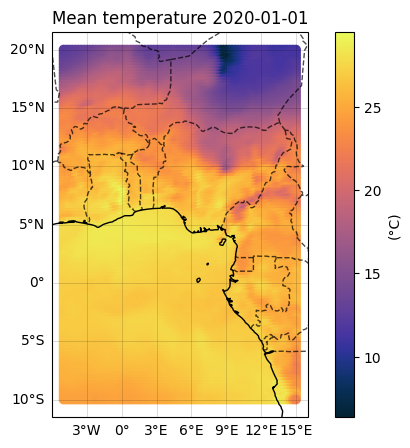

In [ ]:
#2.1/2.2

# Temperature
fig, ax = plot_gdf(
    gdf_selection,
    title=f"Mean temperature {eventDate.strftime('%Y-%m-%d')}",
    legend_title="(°C)",
    value_col='t2m',
    cmap=cmocean.cm.thermal
)
# Precipitation
# fig, ax = plot_gdf(gdf_selection, title=f"Total precipitation {eventDate.strftime('%Y-%m-%d')}", legend_title="(mm)", value_col='tp', cmap=cmocean.cm.rain)


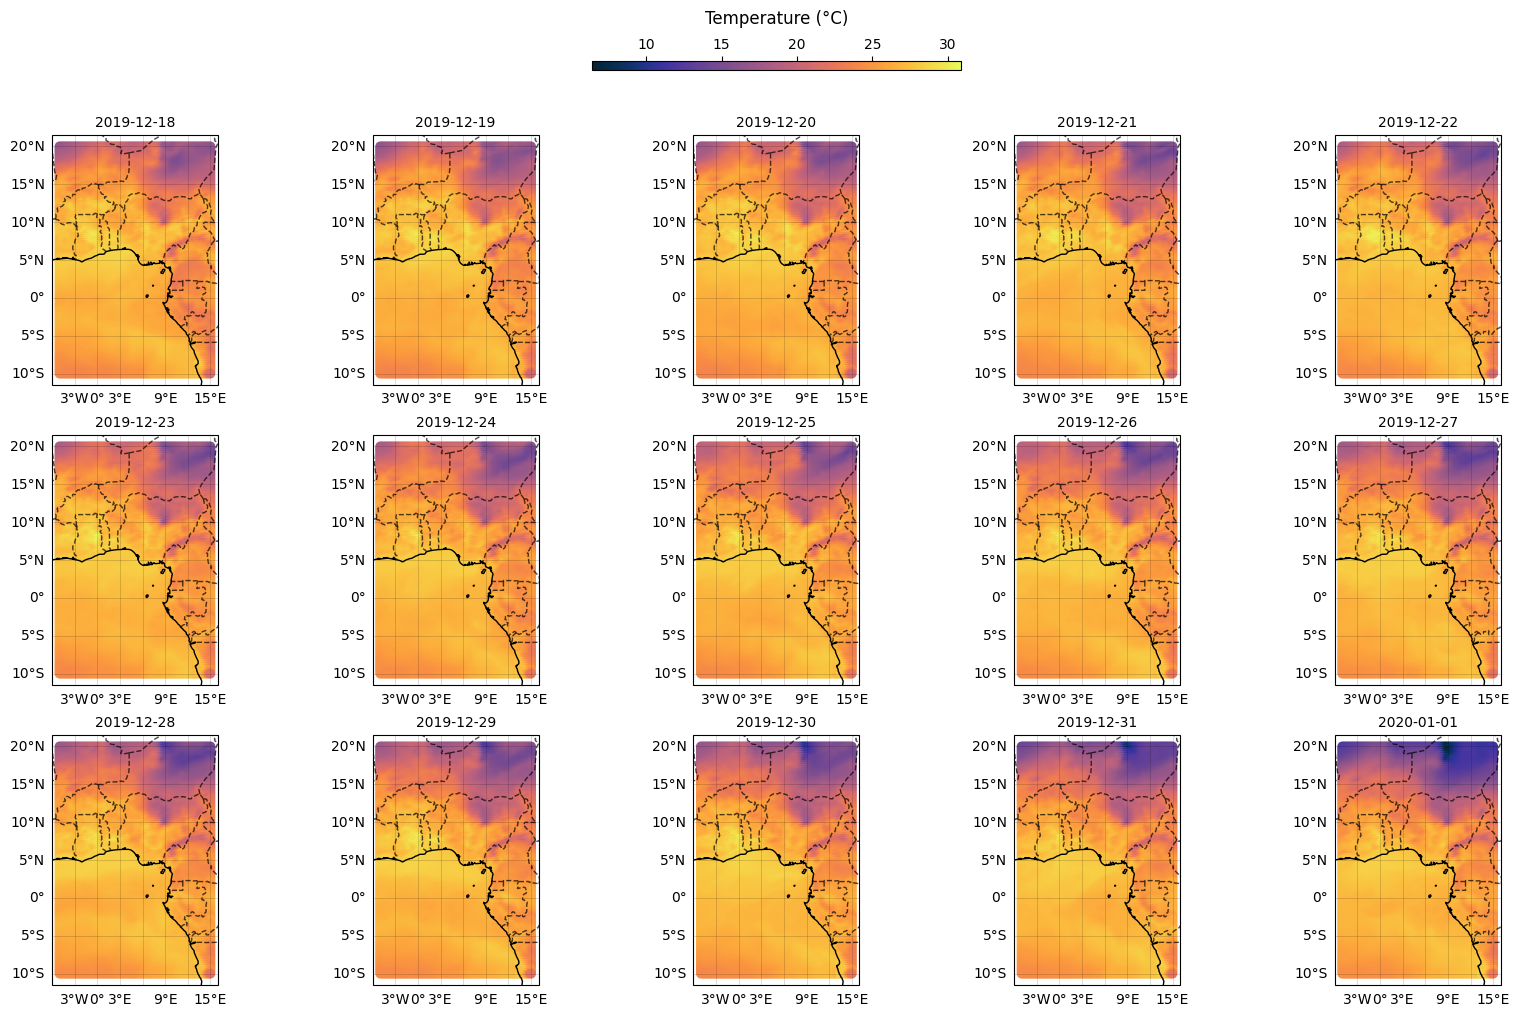

In [6]:
#2.2 a.i

# Temperature
fig, axes = subplot_gdf(
    gdfs,
    datetime_col='valid_time',
    value_col='t2m',
    ncols=5,
    cmap=cmocean.cm.thermal,
    legend_title='Temperature (°C)',
    #suptitle='Mean temperature over 15 days'
)

# # Precipitation
# fig, axes = subplot_gdf(
#     gdfs,
#     datetime_col='valid_time',
#     value_col='tp',
#     ncols=5,
#     cmap=cmocean.cm.rain,
#     legend_title='Precipitation (mm)',
#     #suptitle='Total precipitation over 15 days'
# )

#plt.show()


In [ ]:
#2.2 a.ii 
# plot the 15 day anaomoly. Each day compared to the 15 days surrounding it for 1991-2020
# retrieve data surounding 15 days before leading up to the event and 15 days after the event totalling 45 days each year
start_year = 1991
end_year = 2020

all_gdfs = []

for year in range(start_year, end_year + 1):
    year_start = datetime(year=year, month=eventDate.month, day=eventDate.day) - timedelta(days=29)
    year_end = datetime(year=year, month=eventDate.month, day=eventDate.day) + timedelta(days=15)
    
    all_gdfs.append(DataClient(your_api_key).temperature_2m_mean(bbox, (year_start, year_end)))

final_gdf = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs=all_gdfs[0].crs)


2025-08-18 09:33:11,242 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-18 09:33:13,064 INFO Request ID is f31c9b64-48eb-417d-8fe6-66f20f7e05b1
2025-08-18 09:33:13,144 INFO status has been updated to accepted
2025-08-18 09:33:21,598 INFO status has been updated to successful


2ef8da343fe3c21190a624010b2f4015.nc:   0%|          | 0.00/366k [00:00<?, ?B/s]

2025-08-18 09:33:23,097 INFO Request ID is 4e78c833-8e1e-4cfb-af14-03cea7600ab1
2025-08-18 09:33:23,187 INFO status has been updated to accepted
2025-08-18 09:33:31,599 INFO status has been updated to running
2025-08-18 09:34:38,750 INFO status has been updated to successful


74c6151be15eb072b745b4a7e0caaf28.nc:   0%|          | 0.00/181k [00:00<?, ?B/s]

2025-08-18 09:34:39,667 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-18 09:34:40,501 INFO Request ID is ca725e4d-d516-4a6d-ae9d-b1edec1bf34f
2025-08-18 09:34:40,581 INFO status has been updated to accepted
2025-08-18 09:35:30,456 INFO status has been updated to running
2025-08-18 09:36:34,691 INFO status has been updated to successful


...

69c284bad5ddd6d5f76f043f431c0be1.nc:   0%|          | 0.00/189k [00:00<?, ?B/s]

2025-08-18 10:57:31,843 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-18 10:57:32,266 INFO Request ID is 1c46d3d7-e7a1-4107-a9f1-12a345ab65af
2025-08-18 10:57:32,326 INFO status has been updated to accepted
2025-08-18 10:57:45,818 INFO status has been updated to running
2025-08-18 10:58:47,767 INFO status has been updated to successful


f4cd328da9e93da64637ad9387b12a42.nc:   0%|          | 0.00/328k [00:00<?, ?B/s]

2025-08-18 10:58:48,986 INFO Request ID is 4bd72964-7e91-49cd-b920-8f610be2d32b
2025-08-18 10:58:49,065 INFO status has been updated to accepted
2025-08-18 10:58:57,473 INFO status has been updated to running
2025-08-18 11:00:04,753 INFO status has been updated to successful


6313bc0331d6f7bc4657aec396cf2b85.nc:   0%|          | 0.00/181k [00:00<?, ?B/s]

In [7]:
# save to file
# final_gdf.to_file("../data/1991-2020_tp.gpkg", layer="1991-2020_tp", driver="GPKG")

# load file
final_gdf = gpd.read_file("../data/1991-2020_t2m.gpkg", layer="1991-2020_t2m")


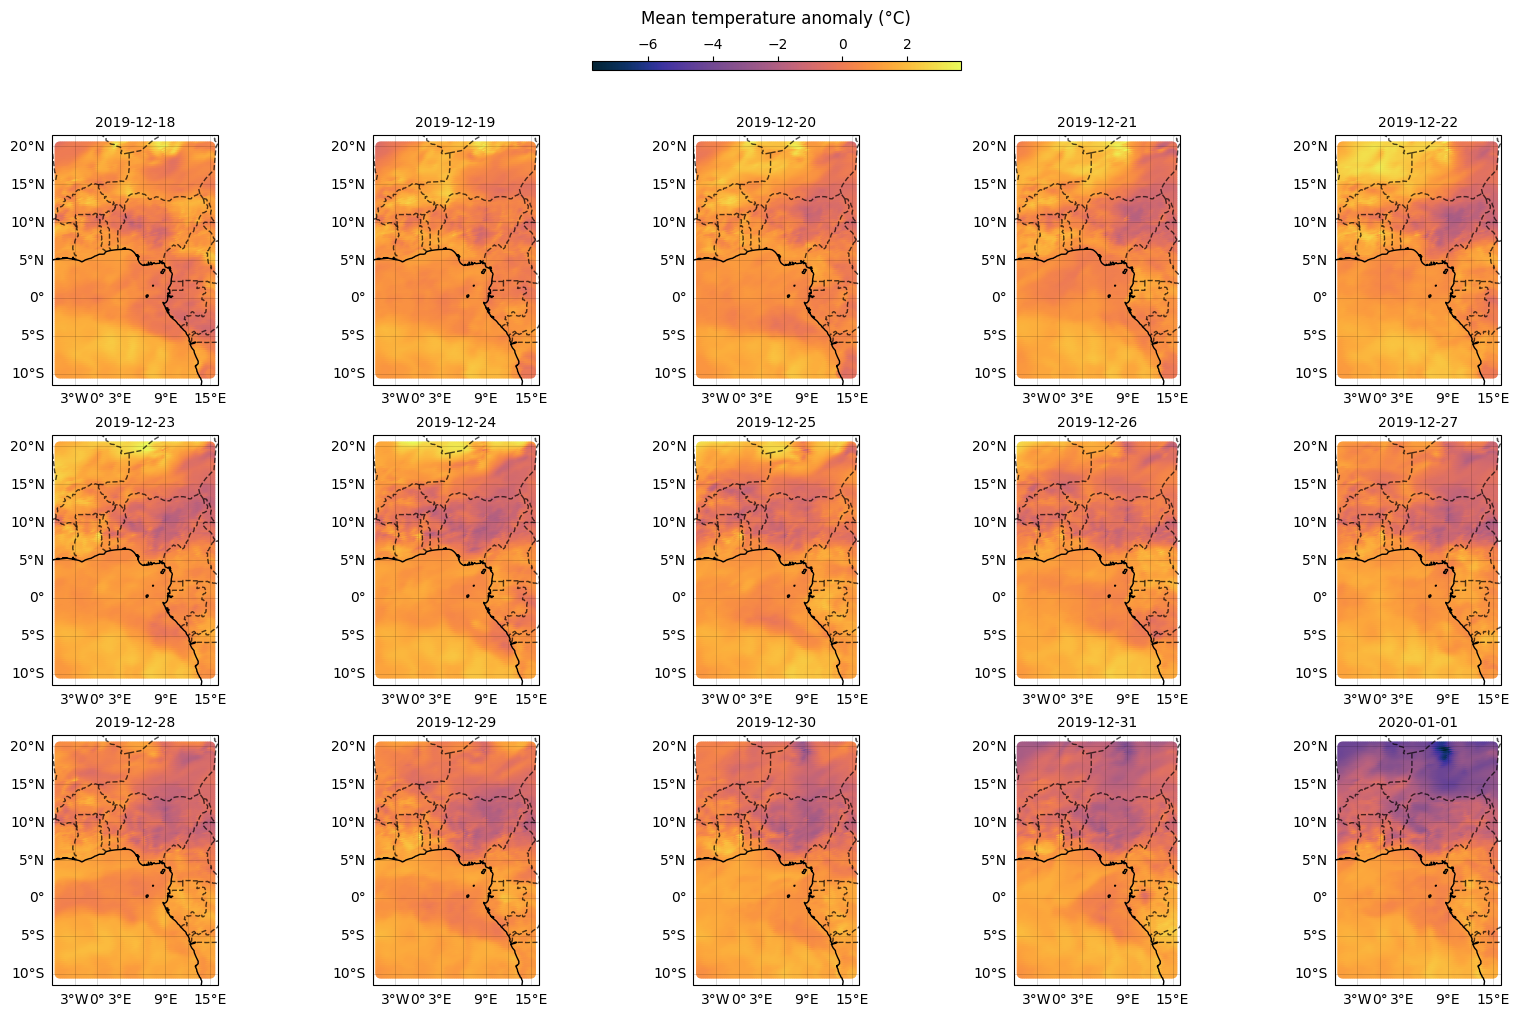

In [8]:
# 2.2 Calculate and show anomaly
anomaly_gdf = calculate_anomaly(final_gdf, gdfs, value_col='t2m')

fig, axes = subplot_gdf(
    anomaly_gdf,
    datetime_col='valid_time',
    value_col='t2m',
    ncols=5,
    cmap=cmocean.cm.thermal,
    legend_title='Mean temperature anomaly (°C)',
    #suptitle='Total precipitation over 15 days'
)

# plt.show()


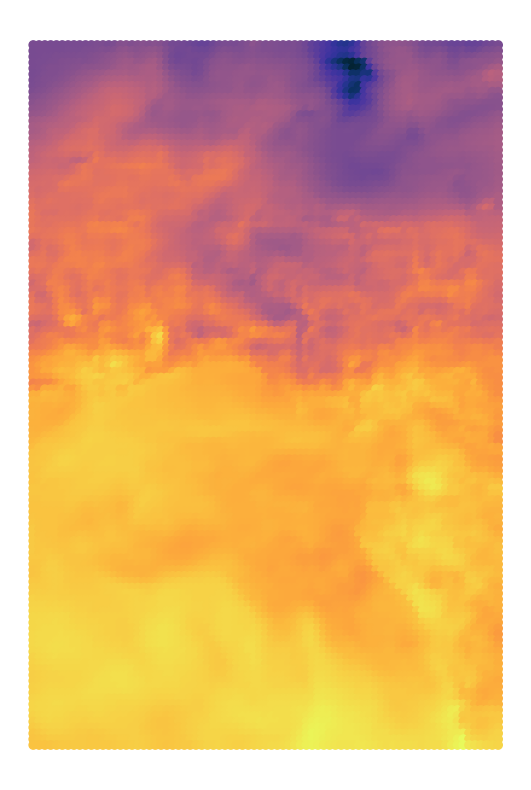

In [21]:
# 2.2 d
# pick a single day and create a figure

selected_gdf_anomoly = anomaly_gdf[(anomaly_gdf['valid_time'] >= datetime(2020,1,1)) & (anomaly_gdf['valid_time'] <= datetime(2020,1,1))]

fig, ax = plt.subplots(
    ncols = 1, nrows = 1, figsize = [8,8], dpi = 100, 
    subplot_kw = {"projection" : ccrs.PlateCarree()}
)

temp_kwargs = {"cmap" : cmocean.cm.thermal}

selected_gdf_anomoly.plot(ax = ax, **temp_kwargs,
    column = 't2m',
)

ax.set_axis_off()
plt.tight_layout()

# Save to memory buffer instead of file
buf = BytesIO()
plt.savefig(buf, format="png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0)
buf.seek(0)

# Encode to base64
img_base64 = base64.b64encode(buf.read()).decode("utf-8")


In [25]:
# Select a region using the C3S-451 Region Picker service
def ddselect_region(regionType, params:Dict[str, Any]=None):
    
    allowed_region_types = ['wraf', 'hydrobasin']
    
    if regionType not in allowed_region_types:
        raise ValueError(f"Invalid regionType '{regionType}'. Allowed values are: {allowed_region_types}")
    
    url = f"http://c3s-451/region-picker/start-m2m/{regionType}"

    #if params != None:
    #    url += urlencode(params)
    
    #response = requests.get(url=url, params=params)
    response = requests.post(url=url, data=params)
    
    poll_url = False
    
    if response.status_code == 200:
        data = response.json()
        print(f"Region Picker started successfully for {regionType}:")
        #print(f"Open the following page in your browser to select a region: ")
        #print(f"\t\t{data['url']}")
        webbrowser.open(data['url'])
        poll_url = data['poll_url']
    else:
        print(f"Failed to start Region Picker for {regionType}. Status code: {response.status_code}")
        print(f"Response: {response.text}")
    
    result = None
    
    if poll_url:
        print(f"Polling for region selection...")
        
        done = False
        
        while not done:
            response = requests.get(poll_url)
            if response.status_code == 200:
                data = response.json()
                if data['done']:
                    done = True
                    result = data['result']
            else:
                print(f"Failed to poll Region Picker for {regionType}. Status code: {response.status_code}")
                print(f"Response: {response.text}")
                break
        
        print("Region selection process done.")
    
    print("Received polygon data:")
    print(result)

    return result

In [ ]:
# 2.2 d
regionType = 'wraf' # 'wraf' or 'hydrobasin'

params = {
    "bbox": bbox,
    "image": img_base64
}

# select region (opens web browser)
result = ddselect_region(regionType, params)
# interpret the result as JSON
data = json.loads(result)

# convert data to polygons and coordinates
polygons, coords = data_2_poly(data)

Region Picker started successfully for hydrobasin:
Polling for region selection...


c:\Python310\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\jasper\AppData\Local\Temp\ipykernel_13932\1725737792.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


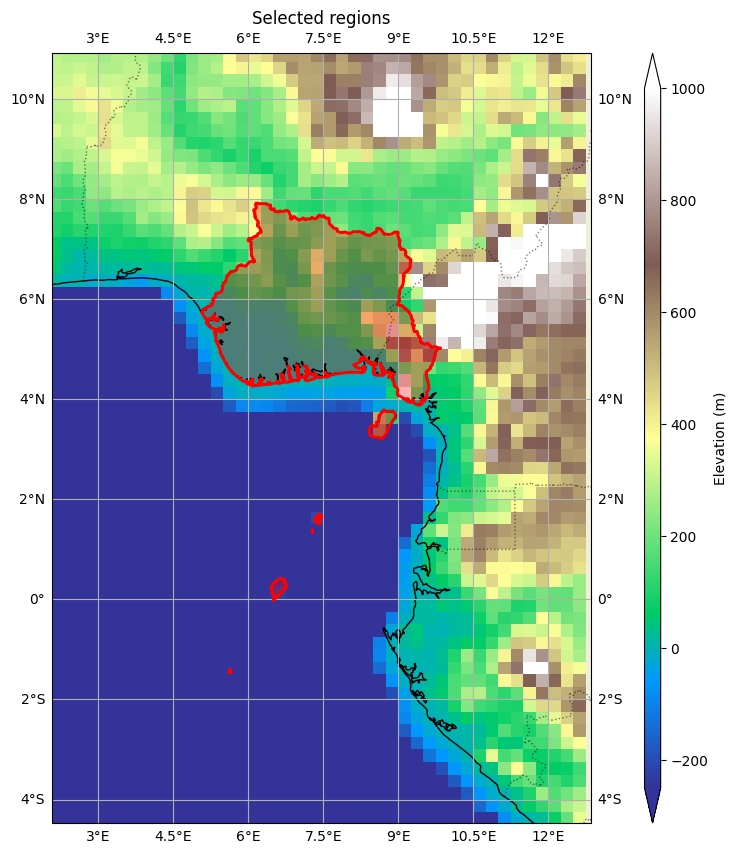

In [12]:
#2.2 d/e
# load elevation data from a NetCDF file
elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

# plot polygon, elevation is optional
fig, ax = plot_poly(polygons, coords, elevation=elevation)

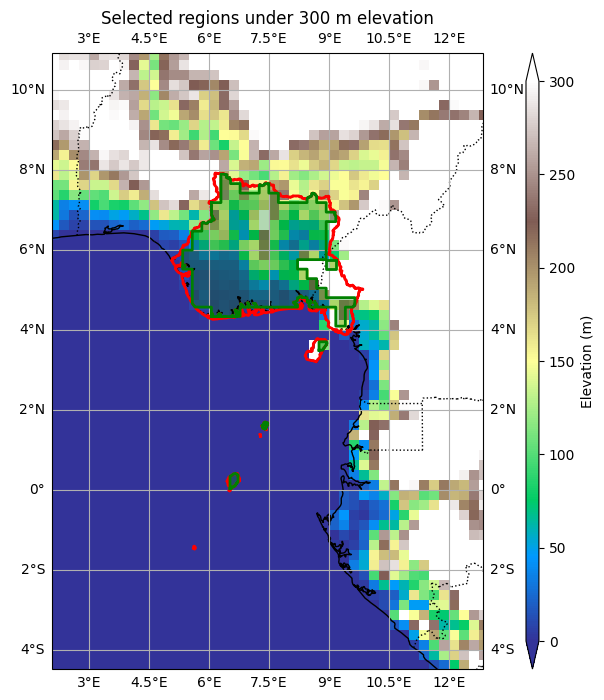

In [13]:
#2.2 e
# plot polygons based on selected region and elevation threshold
elevation_threshold = 300  # meters
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

In [14]:
# 2.2 e
# write polygons to a shapefile
multipoly = unary_union(adjusted_polygons)
gdf = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    # is this using the correct CRS?
gdf.to_file("..\data\sf_studyregion.shp")

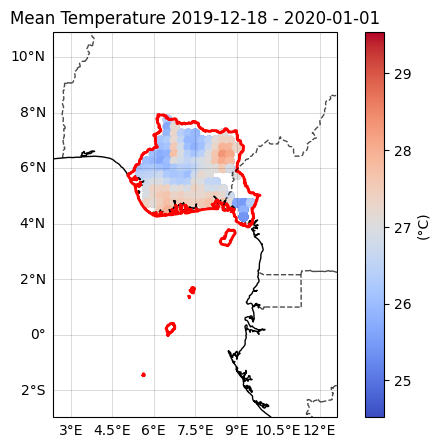

In [15]:
#2.2 e
# intersect gdf with polygons we created to only display data for the selected region and elevation

poly_shp = gpd.read_file("..\data\sf_studyregion.shp")
poly_gdf = gpd.GeoDataFrame(geometry=poly_shp.geometry, crs=poly_shp.crs)

# This is used in the original code but does not work with our poly, since the gdf.overlay works I won't be spending more time to fix this
#rm = regionmask.mask_geopandas(poly_gdf, gdf_selection)

# intersect a GeoDataFrame with the polygon
#intersected = gpd.overlay(daily_gdfs[datetime(2020, 1, 1).date()], poly_gdf, how='intersection')
#intersected = gpd.overlay(gdf_selection, poly_gdf, how='intersection')
intersected = gpd.overlay(gdfs, poly_gdf, how='intersection')

# optional extends for a bigger area
min_lon, min_lat, max_lon, max_lat = poly_gdf.total_bounds
extends = [min_lon - 3, max_lon + 3, min_lat - 3, max_lat + 3]

# display the intersection results
fig, ax = plot_gdf(intersected, title=f"Mean Temperature {startDate.strftime('%Y-%m-%d')} - {eventDate.strftime('%Y-%m-%d')}", legend_title="(°C)", value_col='t2m', cmap='coolwarm', extends=extends, polygons=polygons)
# Maybe add some padding to the results, this should be done in plot.py

# !!! OLD !!!
# display the intersection results
#fig = visualize_geo(intersected, 't2m', 'longitude', 'latitude', backend='plotly', zoom=4, width=500, height=400)
#fig.show()

In [16]:
#2.3
# save the study domain (as shapefile)
intersected.to_file("..\data\sf_studyregion_elev.shp")

c:\Python310\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field valid_time create as date field, though DateTime requested.
  ogr_write(


In [21]:
#2.3
# Create a new bbox from the selected study region
intersected_bbox = intersected.total_bounds

In [ ]:

def plot_timeseries(data, title, x_label, y_label, label_rotation=0, dateformat="%Y-%m-%d", x_ticks=mdates.DayLocator(), color='darkblue', linewidth=2.0, linestyle='-'):

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot directly onto the axes
    data.plot(ax=ax,
              color=color,     # line color
              linewidth=linewidth,        # line width
              linestyle=linestyle        # dashed line; use "-" for solid, ":" for dotted
              )

    

    # Set major ticks to the 1st of each month
    ax.xaxis.set_major_locator(x_ticks)

    # Format the ticks as full dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter(dateformat))

    # Rotate tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(label_rotation)
        label.set_horizontalalignment("right")

    # Set title and axis labels
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # Add grid
    ax.grid(True)

    # Make sure everything fits
    fig.tight_layout()

    return fig, ax

Mean temperature: 27.17445
Mean temperature: valid_time
2019-12-18    27.422749
2019-12-19    27.918270
2019-12-20    27.980932
2019-12-21    27.510851
2019-12-22    27.032232
2019-12-23    27.136312
2019-12-24    26.788841
2019-12-25    27.367483
2019-12-26    27.341496
2019-12-27    27.181929
2019-12-28    27.017881
2019-12-29    26.717142
2019-12-30    26.582203
2019-12-31    26.793295
2020-01-01    26.825140
Name: t2m, dtype: float32


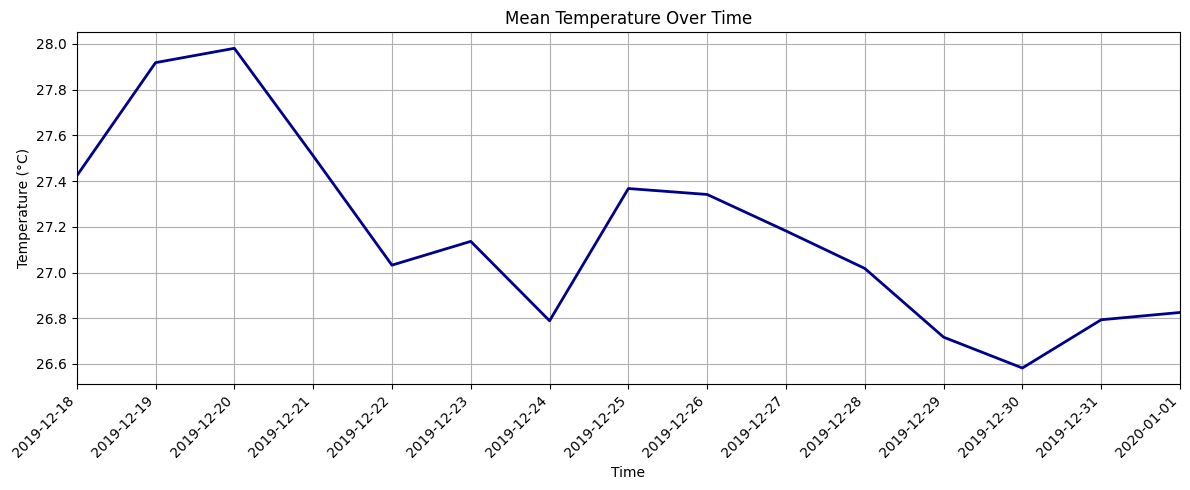

In [17]:
#2.4
#plot timeseries for retrieved data for selected region and elevation

# mean over the entire intersection
mean_temp = intersected["t2m"].mean()
print("Mean temperature:", mean_temp)

# mean temperature per time step
mean_ts = intersected.groupby("valid_time")["t2m"].mean()
print("Mean temperature:", mean_ts)

# Optional: save to NetCDF
mean_ts.to_xarray().to_netcdf("../data/avg_temperature.nc")
# OR CSV
mean_ts.to_csv("../data/avg_temperature.csv")

# plot the mean temperature over time
fig, ax = plot_timeseries(data=mean_ts, 
                title="Mean Temperature Over Time",
                x_label="Time",
                y_label="Temperature (°C)",
                label_rotation=45,
                dateformat="%Y-%m-%d",
                x_ticks=mdates.DayLocator())

In [ ]:
#2.5
# precipitation
event_date = datetime(2023, 7, 1)        # event date
date6 = datetime(2023, 12, 31)
date5 = datetime(2023, 1, 1)

gdfs = DataClient(your_api_key).total_precipitation(intersected_bbox, (date5, date6))
print(gdfs)

2025-08-18 12:40:48,188 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-18 12:40:48,697 INFO Request ID is 1dd84455-53c1-431b-9d93-8b4b33a66d73
2025-08-18 12:40:48,769 INFO status has been updated to accepted
2025-08-18 12:41:10,303 INFO status has been updated to running


KeyboardInterrupt: 

In [22]:
#2.5
# temperature
event_date = datetime(2023, 7, 1)        # event date
date6 = datetime(2023, 12, 31)
date5 = datetime(2023, 1, 1)

gdfs = DataClient(your_api_key).temperature_2m_mean(intersected_bbox, (date5, date6))
print(gdfs)

2025-08-18 14:03:39,833 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-18 14:03:40,558 INFO Request ID is 6b80c9dd-0337-446d-b77b-7b2c86c0beaf
2025-08-18 14:03:40,641 INFO status has been updated to accepted
2025-08-18 14:04:13,647 INFO status has been updated to running
2025-08-18 14:14:00,278 INFO status has been updated to successful


9f08ed56b35809c824bc000fa5638884.nc:   0%|          | 0.00/227k [00:00<?, ?B/s]

      valid_time  latitude  longitude        t2m  number           geometry
0     2023-01-01      7.75       5.50  25.556488       0   POINT (5.5 7.75)
1     2023-01-01      7.75       5.75  25.118591       0  POINT (5.75 7.75)
2     2023-01-01      7.75       6.00  25.522308       0     POINT (6 7.75)
3     2023-01-01      7.75       6.25  26.601807       0  POINT (6.25 7.75)
4     2023-01-01      7.75       6.50  27.267273       0   POINT (6.5 7.75)
...          ...       ...        ...        ...     ...                ...
93070 2023-12-31      4.25       8.50  28.298492       0   POINT (8.5 4.25)
93071 2023-12-31      4.25       8.75  28.039062       0  POINT (8.75 4.25)
93072 2023-12-31      4.25       9.00  26.551086       0     POINT (9 4.25)
93073 2023-12-31      4.25       9.25  25.882568       0  POINT (9.25 4.25)
93074 2023-12-31      4.25       9.50  27.619293       0   POINT (9.5 4.25)

[93075 rows x 6 columns]


In [24]:
#2.5
# creating labels and intersecting with polygons
days = pd.date_range(start = "2020-01-01", end = "2020-12-31")
labelticks = [i+1 for i in range(365) if (days[i].day) == 1]
labels = [days[i].strftime("%b") for i in range(366) if (days[i].day) == 1]

intersected = gpd.overlay(gdfs, poly_gdf, how='intersection')

In [ ]:
def ddn_day_accumulations_gdf(data, column, parameter, labelticks, labels, time_column="valid_time", days=None, ylimit=None):

    fig, axs = plt.subplots(ncols=4, figsize=(20, 3), dpi=100, sharey=True)

    # Ensure datetime and sorted
    data = data.copy()
    data[time_column] = pd.to_datetime(data[time_column])
    data = data.sort_values(time_column)

    for i in range(4):
        ax = axs[i]

        # Determine n-day window
        if days is not None:
            ndays = days[i]
        elif column == 't2m':
            ndays = [1, 3, 7, 14][i]
        elif column == 'tp':
            ndays = [1, 3, 5, 10][i]
        else:
            ndays = [1, 3, 5, 11][i]

        if column is "tp":
            data_nday = (
                data.set_index(time_column)
                    [column]
                    .rolling(ndays, min_periods=1, center=False)
                    .sum()
                    .reset_index()
            )
        else:
            data_nday = (
                data.set_index(time_column)
                    [column]
                    .rolling(ndays, min_periods=1, center=False)
                    .mean()
                    .reset_index()
            )


        # Plot each year in blue
        for y in data_nday[time_column].dt.year.unique():
            data_y = data_nday[data_nday[time_column].dt.year == y]
            ax.plot(
                data_y[time_column].dt.dayofyear,
                data_y[column],
                color="tab:blue",
                alpha=0.3
            )

        # Style the plot
        ax.set_xticks(labelticks)
        ax.set_xticklabels(labels)
        ax.grid(axis="x", color="k", alpha=0.2)
        ax.set_title(f"{ndays}-day accumulated {parameter}")

        # Highlight date window
        ylim = ax.get_ylim()
        print(ylim)

        dayofyear = pd.to_datetime(event_date).dayofyear
        ax.add_patch(Rectangle((dayofyear, ylim[0]), -15, 10000,
                               color="gold", alpha=0.3))
        ax.set_ylim(ylim)

        # Highlight selected year
        year2 = pd.to_datetime(event_date)
        data_y = data_nday[data_nday[time_column] <= year2]
        ax.plot(data_y[time_column].dt.dayofyear, data_y[column], color="k")

    if ylimit is not None:
        ax.set_ylim(0, ylimit)

    return fig, axs

<>:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\jasper\AppData\Local\Temp\ipykernel_7396\4131138138.py:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if column is "tp":


(np.float64(21.36804962158203), np.float64(34.034263610839844))
(np.float64(21.36804962158203), np.float64(34.034263610839844))
(np.float64(21.36804962158203), np.float64(34.034263610839844))
(np.float64(21.36804962158203), np.float64(34.034263610839844))


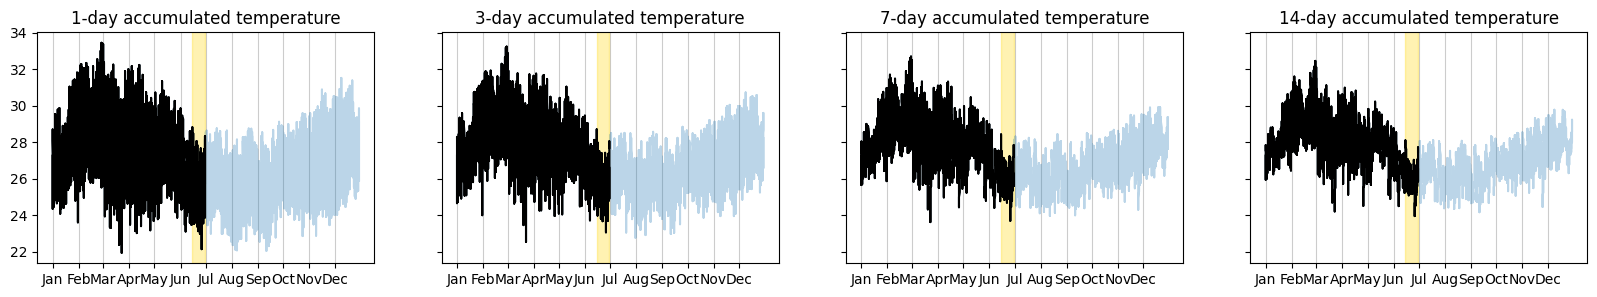

In [26]:
#2.5
# unclear requirements
# current year to the curent date?
# we have now only taken the current year and up to the event date
fig, axs = n_day_accumulations_gdf(data=intersected, column='t2m', parameter='temperature', labelticks=labelticks, labels=labels, event_date=event_date)

In [ ]:
#2.6
# Software

In [ ]:
#2.7
# Documentation


In [ ]:
#2.8
# Markdown?
# software: provide a box in the notebook where motivating factors for the event definition can be noted (2.8a). Refer to step 2.8.

In [ ]:
#2.9
# Software

In [ ]:
#2.10
# read station data time series from .xls

In [ ]:
#2.11
# Software
# this is intended to be a figure that will be published on the factsheet, so it should be the larger domain, that the user has specified earlier on, which incorporates the study domain which should be outlined.

In [ ]:
#2.12
# Documentation

In [ ]:
#2.13
# unclear requirements
# Software
# this is to aid the writing process but can still be part of the same notebook. For discussion: shouldn't this come before the event definition procedure? It makes sense to have an idea of the development before making a decision on the event definition.

In [ ]:
#2.14
# Documentation

In [ ]:
#2.15
# unclear requirements